# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer

# Airfoil Self-Noise

The first notebook was a set of problems where we already knew the answer, which is the only
honest way to check whether a prior helped. 

Now, we will spend a bit of time on a problem where we do not know the answer for.

It is a real dataset,
measured in a real wind tunnel, and the rest of the session is yours to poke at.

For the next half hour: we load the data, fit a boosted-tree model to have an okay baseline, and then make three attempts at an equation.
---

Julia takes a while to wake up, so let's start that now and read while it happens.

In [1]:
# Uncomment on Colab. Locally you should already have these from this morning.
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#                 "pysr", "xgboost", "scikit-learn"], check=True)

In [1]:
import os
# Julia fixes its thread count at startup, so this has to happen before `import pysr`.
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time

import numpy as np
import pandas as pd

t0 = time.time()
import pysr
from pysr import PySRRegressor
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s")

import session2_data as s2
from session2_data import (load_airfoil, split, view, r2, explained_by,
                           front_scores, best_on_front, shortest_above)

# Same determinism switch as this morning. Drop it once you start exploring and the
# searches get noticeably faster, at the cost of not reproducing exactly.
REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

pysr 1.5.10 imported in 27s


---

## 1. What was measured

NASA put a series of NACA 0012 blade sections into an anechoic wind tunnel, ran them at a
range of speeds and angles of attack, and recorded the noise each blade made *by itself*. 

Each row is one one-third-octave frequency band of one run. Five numbers set the condition and
the sixth is what the microphones heard.

In [2]:
df = load_airfoil()

for c, (what, unit) in s2.MEANING.items():
    print(f"  {c:6s} {what:58s} [{unit}]")
print()
df.head()

  freq   centre frequency of the one-third-octave band              [Hz]
  aoa    geometric angle of attack                                  [degrees]
  chord  chord length of the blade section                          [m]
  U      free-stream velocity                                       [m/s]
  delta  suction-side boundary-layer displacement thickness         [m]
  spl    scaled sound pressure level                                [dB]



,freq,aoa,chord,U,delta,spl,St
0,800,0.0,0.3048,71.3,0.002663,126.201,0.029884
1,1000,0.0,0.3048,71.3,0.002663,125.201,0.037354
2,1250,0.0,0.3048,71.3,0.002663,125.951,0.046693
3,1600,0.0,0.3048,71.3,0.002663,127.591,0.059767
4,2000,0.0,0.3048,71.3,0.002663,127.461,0.074709


In [3]:
df[["freq", "aoa", "chord", "U", "delta", "spl"]].describe().T

,count,mean,std,min,25%,50%,75%,max
freq,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
aoa,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
chord,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
U,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
delta,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
spl,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


Two things to notice in that table before we fit anything. Frequency runs from 200 Hz to
20 kHz, a factor of a hundred, and the displacement thickness covers a factor of a hundred and
fifty. The target does not: the whole dataset lives inside a 38 dB window. So four of the five
inputs are spread over decades while the output is not.

And the wind speed only ever takes four values, the chord only six. This was a designed
experiment, not a log of whatever the weather happened to do.

findfont: Failed to find font weight medium, now using 400.


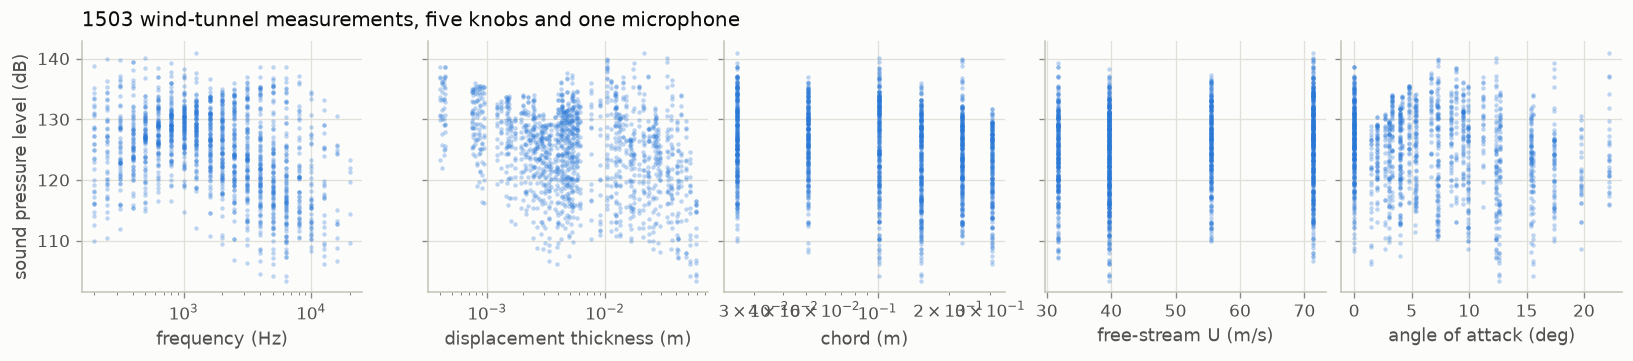

In [4]:
s2.plot_overview(df);

No single panel shows a curve. Each one is a band, because the other four columns are moving
underneath it. That is what makes this a fitting problem rather than a plotting problem.

---

## 2. A benchmark

Before trying to write an equation it is worth knowing what is achievable and understand the data.

Everything from here on is scored the same way, and the training/test split is the same. 

In [5]:
from xgboost import XGBRegressor

train, test = split(df)
y = df["spl"].values

X_all, _ = view(df, "raw")
trees = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.06).fit(X_all[train], y[train])

BASELINE = r2(trees.predict(X_all[test]), y[test])
print(f"400 boosted trees:   held-out R^2 = {BASELINE:.3f}")

400 boosted trees:   held-out R^2 = 0.958


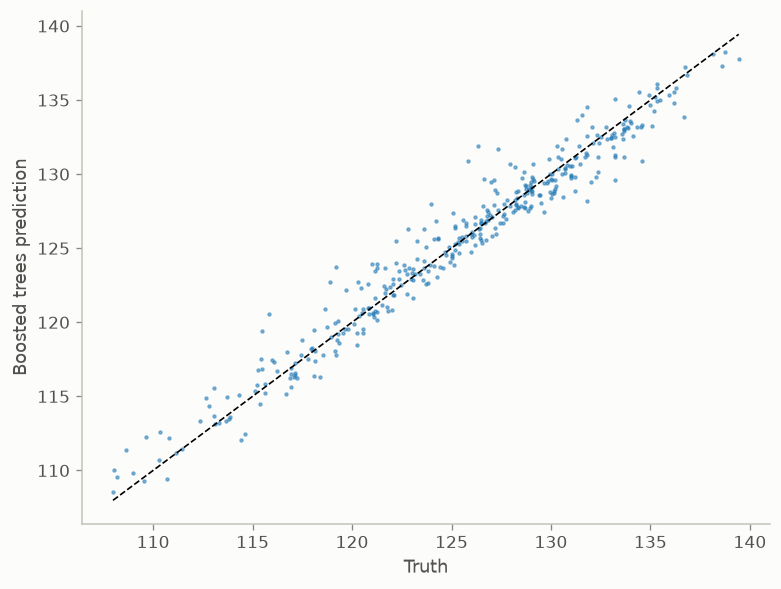

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(y[test], trees.predict(X_all[test]), s=3, alpha=0.5)
lims = [y[test].min(), y[test].max()]
ax.plot(lims, lims, color="k", ls="--", lw=1)
ax.set_xlabel("Truth")
ax.set_ylabel("Boosted trees prediction")
ax.grid(False)

---

## 3. Attempt one: the columns exactly as measured

The obvious first move. Five columns in, sound pressure level out, a reasonable set of
operators, and no opinion at all about what any of it means.

In [8]:
from pysr import PySRRegressor, TemplateExpressionSpec

In [16]:
SEARCH = dict(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "exp", "log"],
    maxsize=50,          # largest expression the search may build
    niterations=40,      # how long the populations get to evolve
    random_state=0,
    **REPRO,
)

no_nesting = dict(
    nested_constraints={
        "exp": {"exp": 0, "log": 1},
        "log": {"log": 0, "exp": 0},
        "square": {"square": 0}
    },
)

separable = TemplateExpressionSpec("log(f(x1*x5/x4)) + log(g(x5/x3)) + log(h(x1*x3/x4)) + log(k(x2))", expressions=["f", "g", "h", "k"],
                                   variable_names=["x1", "x2", "x3", "x4", "x5"])
# Each of the three fits below takes roughly a minute on a laptop that is not busy
# doing something else. If yours is, drop niterations to 20 — the story survives it,
# the equations just come out a little shorter.

X_raw, names_raw = view(df, "raw")

raw_model = PySRRegressor(expression_spec=separable, **SEARCH, **no_nesting)
raw_model.fit(X_raw[train], y[train], variable_names=names_raw)

raw_front = front_scores(raw_model, X_raw[test], y[test])
raw_front

e:\Graduate Studies\Second Year Summer I & II\IAIFI summer school\.venv\Lib\site-packages\pysr\sr.py:1469: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(


,complexity,loss,test_r2,equation
0,4,48.889545,-0.010165,f = 3.099138e21; g = 4.899632e21; h = 1.309435...
1,6,39.293278,0.199327,f = 1.8649776e13 / #1; g = 8.352157e13; h = 1....
2,7,33.072070,0.326861,f = 2.4818804e13 / square(#1); g = 1.8711887e1...
3,9,28.912004,0.401338,f = 3.8457544e13 / square(#1); g = 2.7294463e1...
4,10,26.920713,0.492794,f = 2.91192e8 / square(exp(#1) + -1.0851657); ...
5,11,26.566660,0.401430,f = 7.371293e12 / square(#1); g = 1.1926908e13...
6,12,24.548431,0.474576,f = 2.0276968e13 / square(#1); g = 2.0276968e1...
7,13,23.475063,0.497450,f = 2.5390552e12 / square(#1); g = 2.7012249e1...
8,15,18.734402,0.639776,f = 3.443845e8 / square(exp(#1) + -1.112772); ...
9,17,17.136211,0.651936,f = 3.7023904e8 / square(exp(#1) + -1.1096705)...


In [19]:
# Get the best equation
best_equation = raw_front.loc[raw_front["test_r2"].idxmax(), "equation"]

from sympy import simplify, symbols, log, exp
freq, aoa, chord, U, delta = symbols('freq aoa chord U delta')
simplified_equation = simplify(best_equation)
simplified_equation

0.07712038*U - 1.19930867050997*log(square(square(0.59466225*aoa - 0.6075825*delta*freq)) + 5.430007) + 128.4162

That table is the Pareto front with one column added. `loss` is what the search minimised, so
it can only fall as complexity rises. `test_r2` is those same equations scored on the quarter
of the rows they never saw, and *that* one is free to go back down — which is how you catch an
equation that has started memorising instead of explaining.

Nobody asked it to do that. Handed frequency in hertz and thickness in metres, the first
structural thing the search builds is the logarithm of their product — and then it squares it.
It is spending its opening nodes rediscovering that this problem lives on a log scale, and that
frequency and thickness belong together, before it can spend a single node on anything else.

That is the cost of handing over raw columns. Not that the search is weak, but that we made it
buy something we already knew.

In [21]:
best_raw = best_on_front(raw_front)
print(f"\ncomplexity {best_raw['complexity']}    held-out R^2 = {best_raw['test_r2']:.3f}"
      f"    (trees: {BASELINE:.3f})")


complexity 22    held-out R^2 = 0.632    (trees: 0.958)


# Can you do better? 

Go give it a try!